# Análisis Exploratorio de Datos — Hotel Bookings

Este notebook realiza un análisis exploratorio (EDA) del dataset de reservas de hotel.  
El objetivo es entender la estructura de los datos, detectar patrones relevantes y explorar las variables que podrían influir en la cancelación de reservas.

---

## Diccionario de variables

A continuación se describe el significado de cada columna del dataset:

### Variables de huéspedes
| Variable | Tipo | Descripción |
|---|---|---|
| `no_of_adults` | Numérica | Número de adultos incluidos en la reserva |
| `no_of_children` | Numérica | Número de niños incluidos en la reserva |
| `repeated_guest` | Binaria | Indica si el huésped ya se había hospedado antes (1 = sí, 0 = no) |

### Variables de estadía
| Variable | Tipo | Descripción |
|---|---|---|
| `no_of_weekend_nights` | Numérica | Número de noches de fin de semana (sáb/dom) incluidas en la reserva |
| `no_of_week_nights` | Numérica | Número de noches entre semana (lun–vie) incluidas en la reserva |
| `type_of_meal_plan` | Categórica | Plan de comidas seleccionado: `Meal Plan 1` (desayuno), `Meal Plan 2` (media pensión), `Meal Plan 3` (pensión completa), `Not Selected` (sin plan) |
| `required_car_parking_space` | Binaria | Si el huésped solicitó espacio de estacionamiento (1 = sí, 0 = no) |

### Variables de fecha de llegada
| Variable | Tipo | Descripción |
|---|---|---|
| `lead_time` | Numérica | Número de días entre la fecha de la reserva y la fecha de llegada |
| `arrival_year` | Numérica | Año de llegada planificado |
| `arrival_month` | Numérica | Mes de llegada planificado (1 = enero … 12 = diciembre) |
| `arrival_date` | Numérica | Día del mes de llegada planificado |

### Variables de historial del huésped
| Variable | Tipo | Descripción |
|---|---|---|
| `no_of_previous_cancellations` | Numérica | Número de reservas anteriores que el huésped canceló |
| `no_of_previous_bookings_not_canceled` | Numérica | Número de reservas anteriores que el huésped **no** canceló |

### Variables económicas y de servicio
| Variable | Tipo | Descripción |
|---|---|---|
| `avg_price_per_room` | Numérica | Precio promedio por habitación por noche (en USD) |
| `no_of_special_requests` | Numérica | Número de solicitudes especiales hechas por el huésped (ej. cama adicional, vista al mar) |

### Variable objetivo
| Variable | Tipo | Descripción |
|---|---|---|
| `booking_status` | Categórica | Estado final de la reserva: `Canceled` (cancelada) o `Not_Canceled` (completada) |

---

## 1. Importación de librerías

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Carga del dataset

Cargamos el archivo Excel y hacemos una primera revisión básica: dimensiones, nombres de columnas y primeras filas.

In [14]:
df = pd.read_csv('HotelData.csv')

print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
print('\nColumnas:', df.columns.tolist())
df.head()

Filas: 25,811  |  Columnas: 16

Columnas: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled


## 3. Tipos de datos y valores nulos

Revisamos el tipo de dato de cada columna y verificamos si hay valores faltantes.  
Esto es esencial antes de cualquier análisis para saber si necesitamos limpiar o imputar datos.

In [15]:
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().mean() * 100).round(2)
})
print(info.to_string())

                                         Tipo  Nulos  % Nulos
no_of_adults                            int64      0      0.0
no_of_children                          int64      0      0.0
no_of_weekend_nights                    int64      0      0.0
no_of_week_nights                       int64      0      0.0
type_of_meal_plan                      object      0      0.0
required_car_parking_space              int64      0      0.0
lead_time                               int64      0      0.0
arrival_year                            int64      0      0.0
arrival_month                           int64      0      0.0
arrival_date                            int64      0      0.0
repeated_guest                          int64      0      0.0
no_of_previous_cancellations            int64      0      0.0
no_of_previous_bookings_not_canceled    int64      0      0.0
avg_price_per_room                    float64      0      0.0
no_of_special_requests                  int64      0      0.0
booking_

> **Observación:** El dataset no contiene valores nulos — no requiere imputación.

## 4. Estadísticas descriptivas

Las estadísticas básicas (media, mediana, desviación estándar, mínimo y máximo) nos dan una idea general de la distribución de las variables numéricas.

In [16]:
df.describe().round(2)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00,25811.00
mean,1.89,0.14,0.88,2.26,0.04,65.55,2017.85,7.33,15.75,0.03,0.03,0.21,105.75,0.75
std,0.53,0.46,0.89,1.51,0.20,67.45,0.36,3.14,8.85,0.18,0.41,2.08,37.92,0.82
min,0.00,0.00,0.00,0.00,0.00,0.00,2017.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,0.00,0.00,1.00,0.00,12.00,2018.00,5.00,8.00,0.00,0.00,0.00,80.75,0.00
50%,2.00,0.00,1.00,2.00,0.00,44.00,2018.00,8.00,16.00,0.00,0.00,0.00,100.00,1.00
75%,2.00,0.00,2.00,3.00,0.00,98.00,2018.00,10.00,23.00,0.00,0.00,0.00,127.00,1.00
max,4.00,10.00,7.00,17.00,1.00,443.00,2018.00,12.00,31.00,1.00,13.00,58.00,540.00,5.00


## 5. Variable objetivo: `booking_status`

Analizamos la distribución de la variable que queremos predecir o entender: si una reserva fue cancelada o no.  
Un desbalance importante entre clases puede afectar modelos predictivos.

Distribución de booking_status:
  Not_Canceled: 18,542 (71.8%)
  Canceled: 7,269 (28.2%)


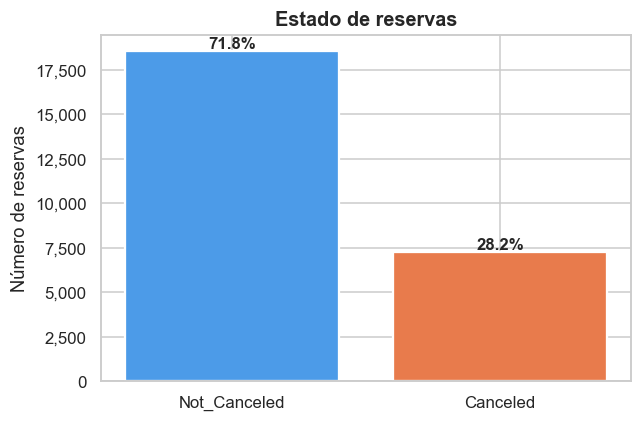

In [17]:
counts = df['booking_status'].value_counts()
pcts   = df['booking_status'].value_counts(normalize=True) * 100

print('Distribución de booking_status:')
for label in counts.index:
    print(f'  {label}: {counts[label]:,} ({pcts[label]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#4C9BE8', '#E87B4C']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Estado de reservas', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de reservas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 6. Distribución de variables numéricas

Visualizamos la distribución de las principales variables numéricas con histogramas.  
Esto nos ayuda a detectar sesgos, valores extremos o distribuciones inusuales.

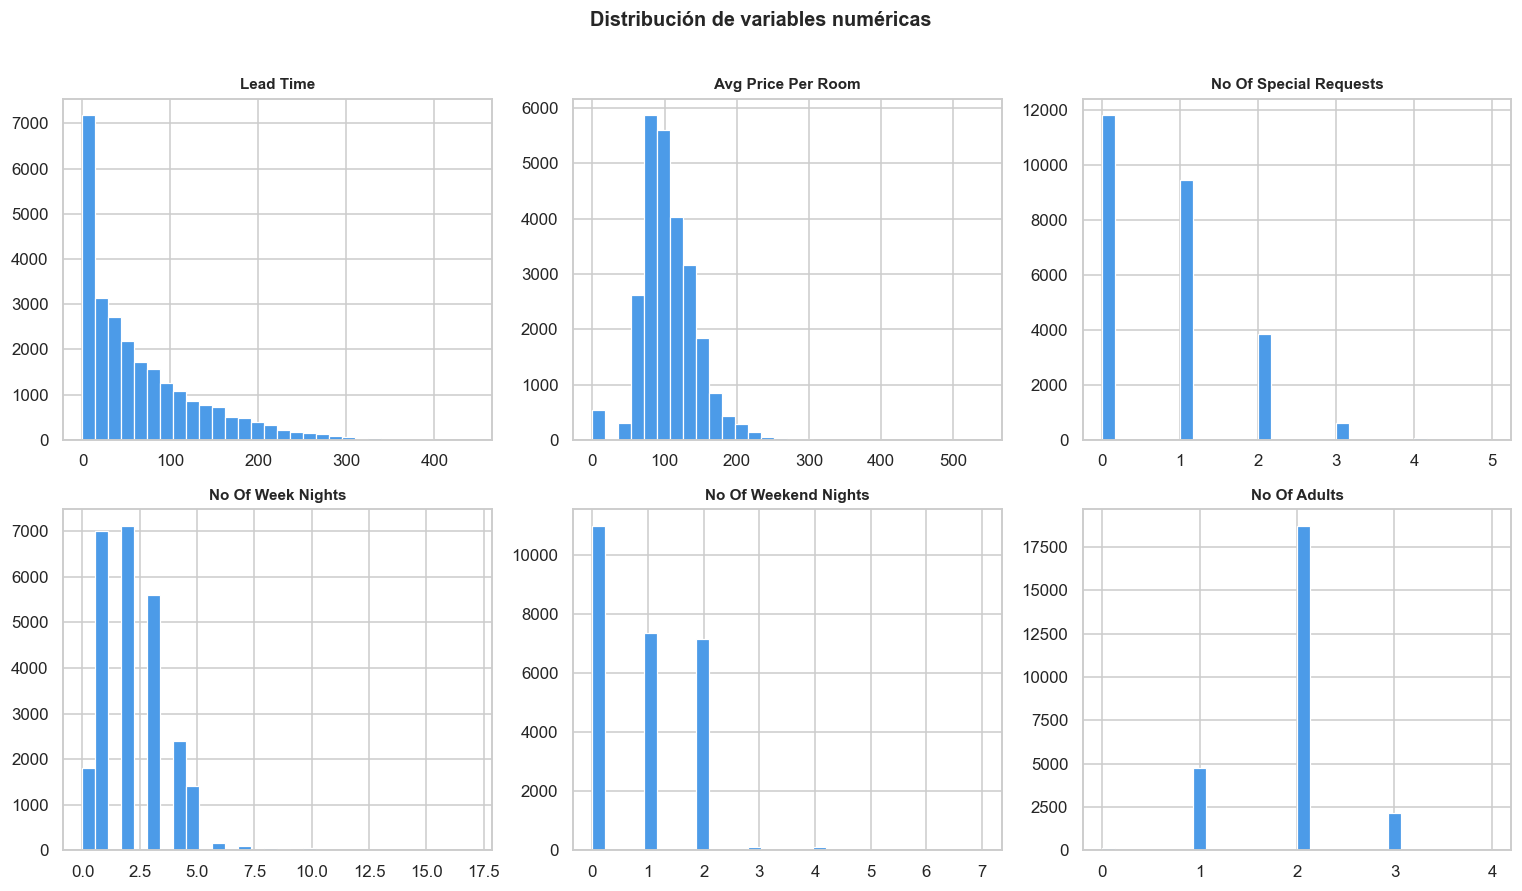

In [18]:
num_cols = ['lead_time', 'avg_price_per_room', 'no_of_special_requests',
            'no_of_week_nights', 'no_of_weekend_nights', 'no_of_adults']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    df[col].hist(ax=ax, bins=30, color='#4C9BE8', edgecolor='white', linewidth=0.8)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Distribución de variables numéricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Variables categóricas

Exploramos las variables categóricas del dataset: el plan de comida seleccionado y si el huésped es recurrente.  
Entender su distribución ayuda a detectar grupos dominantes en el dataset.

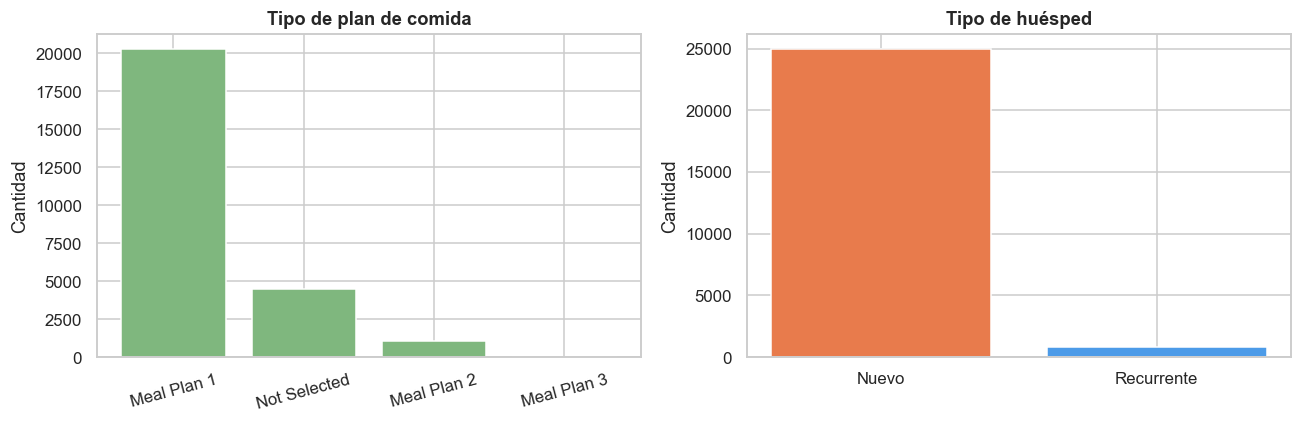

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plan de comida
meal_counts = df['type_of_meal_plan'].value_counts()
axes[0].bar(meal_counts.index, meal_counts.values, color='#7FB77E', edgecolor='white')
axes[0].set_title('Tipo de plan de comida', fontweight='bold')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=15)

# Huésped recurrente
rep_counts = df['repeated_guest'].value_counts().rename({0: 'Nuevo', 1: 'Recurrente'})
axes[1].bar(rep_counts.index, rep_counts.values, color=['#E87B4C', '#4C9BE8'], edgecolor='white')
axes[1].set_title('Tipo de huésped', fontweight='bold')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

## 8. Tasa de cancelación por variables clave

Analizamos cómo varía la tasa de cancelación según el plan de comida, si el huésped es recurrente  
y si requirió estacionamiento. Esto puede revelar perfiles de mayor riesgo de cancelación.

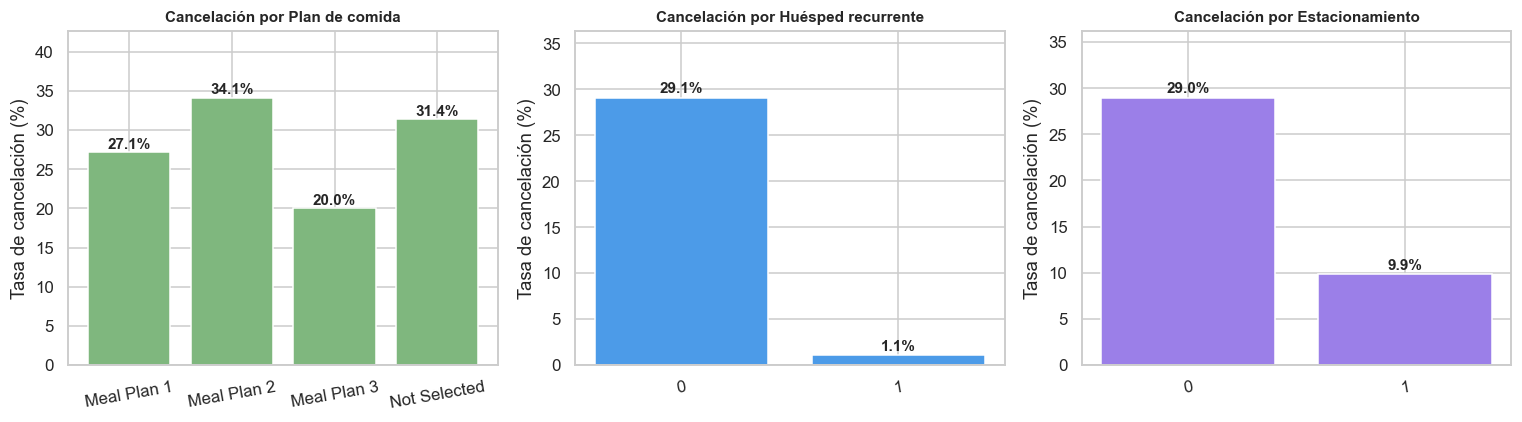

In [20]:
df['canceled'] = (df['booking_status'] == 'Canceled').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

groups = [
    ('type_of_meal_plan',          'Plan de comida',       '#7FB77E'),
    ('repeated_guest',             'Huésped recurrente',   '#4C9BE8'),
    ('required_car_parking_space', 'Estacionamiento',      '#9B7FE8'),
]

for ax, (col, title, color) in zip(axes, groups):
    rates = df.groupby(col)['canceled'].mean() * 100
    ax.bar(rates.index.astype(str), rates.values, color=color, edgecolor='white')
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Cancelación por {title}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Tasa de cancelación (%)')
    ax.set_ylim(0, rates.max() * 1.25)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

## 9. Lead time vs. cancelación

El `lead_time` es la cantidad de días de anticipación con que se hizo la reserva.  
Es razonable suponer que reservas con mucha anticipación tienen mayor probabilidad de cancelarse.

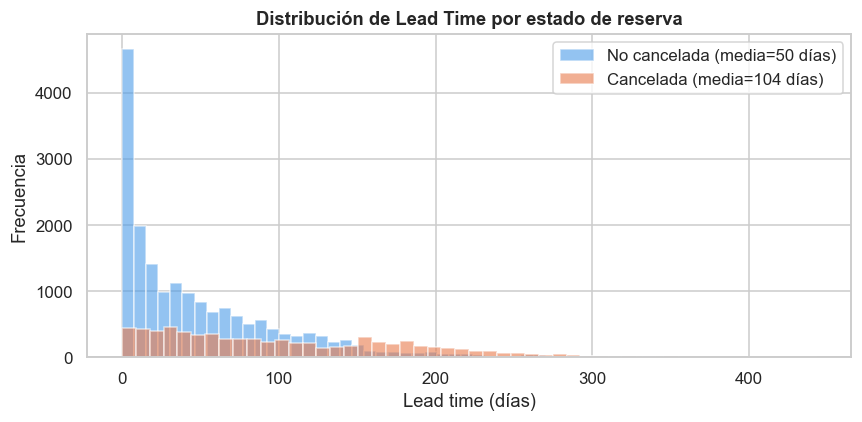

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
for status, color, label in [('Not_Canceled', '#4C9BE8', 'No cancelada'), ('Canceled', '#E87B4C', 'Cancelada')]:
    subset = df[df['booking_status'] == status]['lead_time']
    ax.hist(subset, bins=50, alpha=0.6, color=color, label=f'{label} (media={subset.mean():.0f} días)')

ax.set_title('Distribución de Lead Time por estado de reserva', fontweight='bold')
ax.set_xlabel('Lead time (días)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Precio promedio por habitación

Comparamos la distribución del precio promedio por habitación entre reservas canceladas y no canceladas.  
Precios más altos podrían estar asociados a mayor tasa de cancelación.

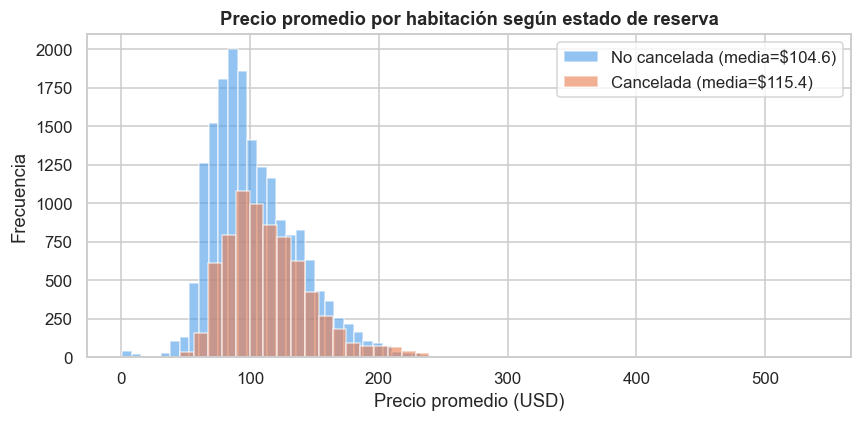

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
for status, color, label in [('Not_Canceled', '#4C9BE8', 'No cancelada'), ('Canceled', '#E87B4C', 'Cancelada')]:
    subset = df[df['booking_status'] == status]['avg_price_per_room']
    subset = subset[subset > 0]  # excluimos precio 0 (probable error de registro)
    ax.hist(subset, bins=50, alpha=0.6, color=color, label=f'{label} (media=${subset.mean():.1f})')

ax.set_title('Precio promedio por habitación según estado de reserva', fontweight='bold')
ax.set_xlabel('Precio promedio (USD)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Reservas por mes de llegada

Analizamos la estacionalidad: cuántas reservas hay por mes y cómo se distribuyen las cancelaciones a lo largo del año.

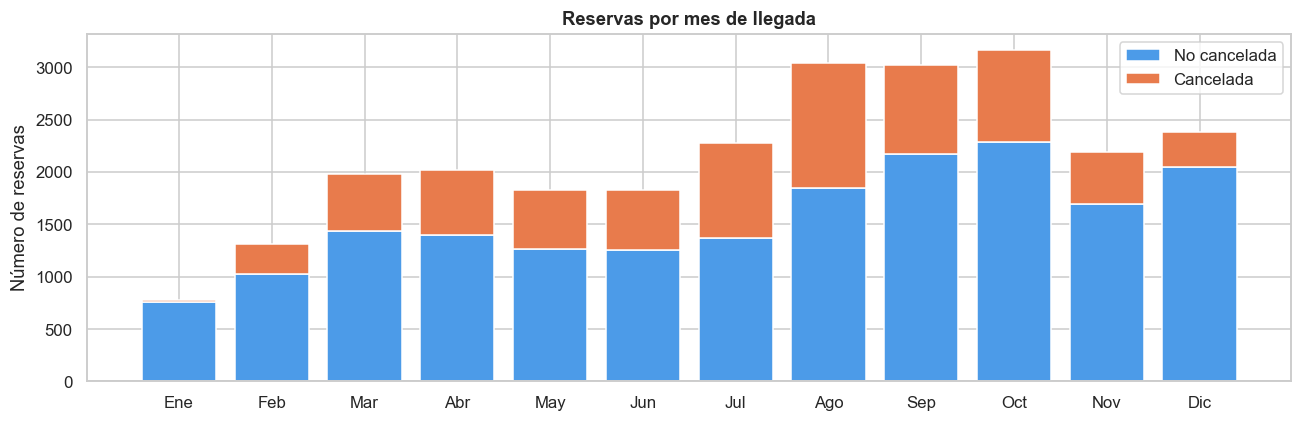

In [23]:
meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
         7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

monthly = df.groupby('arrival_month').agg(
    total=('canceled', 'count'),
    canceladas=('canceled', 'sum')
).reset_index()
monthly['no_canceladas'] = monthly['total'] - monthly['canceladas']
monthly['mes'] = monthly['arrival_month'].map(meses)

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(monthly))
ax.bar(x, monthly['no_canceladas'], label='No cancelada', color='#4C9BE8')
ax.bar(x, monthly['canceladas'], bottom=monthly['no_canceladas'], label='Cancelada', color='#E87B4C')
ax.set_xticks(list(x))
ax.set_xticklabels(monthly['mes'])
ax.set_title('Reservas por mes de llegada', fontweight='bold')
ax.set_ylabel('Número de reservas')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Matriz de correlación

La matriz de correlación muestra la relación lineal entre variables numéricas.  
Valores cercanos a 1 o -1 indican correlaciones fuertes; cercanos a 0, poca o ninguna relación.

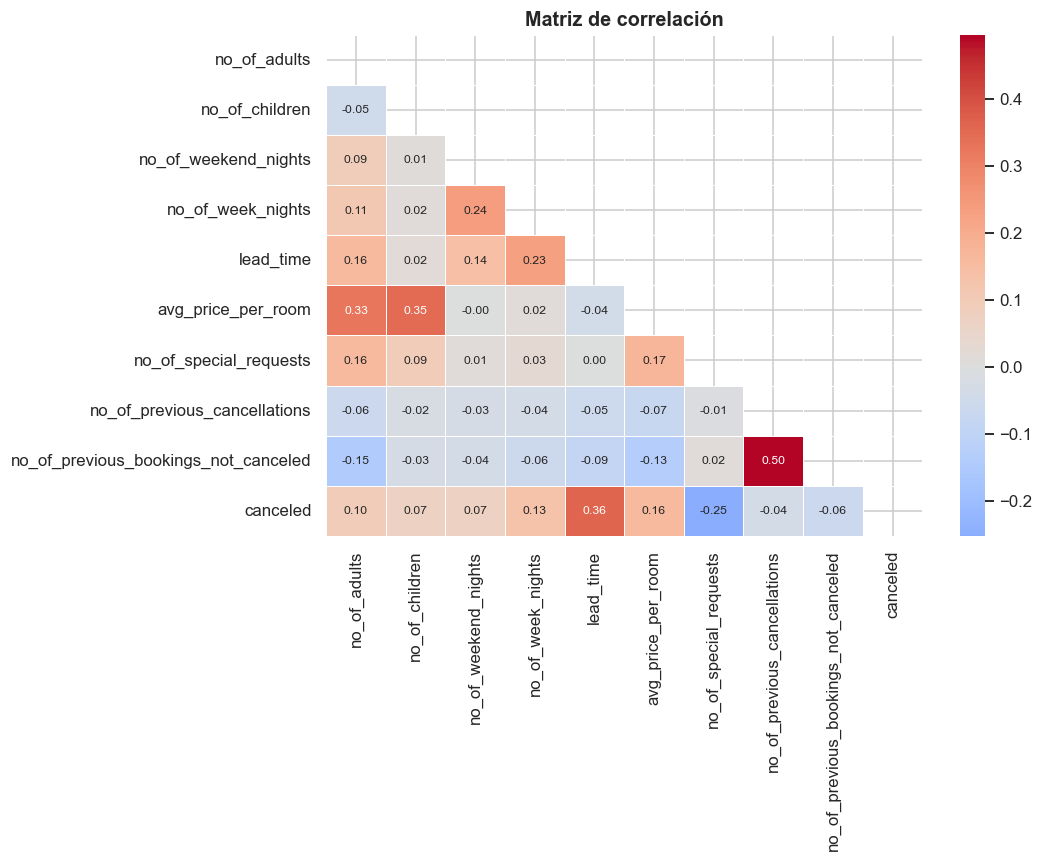

In [24]:
num_df = df[['no_of_adults','no_of_children','no_of_weekend_nights','no_of_week_nights',
             'lead_time','avg_price_per_room','no_of_special_requests',
             'no_of_previous_cancellations','no_of_previous_bookings_not_canceled','canceled']]

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de correlación', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 13. Resumen de hallazgos

| # | Hallazgo |
|---|----------|
| 1 | El dataset tiene **25,811 reservas** y **16 variables**; sin valores nulos. |
| 2 | Alrededor del **67%** de las reservas no se cancelaron y el **33%** sí. |
| 3 | Las reservas canceladas tienen un **lead time notablemente mayor** (más días de anticipación). |
| 4 | Los **huéspedes recurrentes** tienen una tasa de cancelación mucho más baja que los nuevos. |
| 5 | El **plan "Not Selected"** tiene la mayor tasa de cancelación entre los planes de comida. |
| 6 | Quienes solicitan **estacionamiento** cancelan menos. |
| 7 | El precio promedio por habitación es ligeramente más alto en reservas canceladas. |
| 8 | Los meses de **octubre y noviembre** concentran mayor volumen de reservas. |
| 9 | `lead_time` y `no_of_previous_cancellations` son las variables con mayor correlación con la cancelación. |